# `verify_2026b.ipynb` — v2026b method comparison

Compares the two v2026b NRT-extension products against each other:

* `outputs/gml_ff_co2_2026b_assumed.nc` — gas/oil +2.5%, coal/flaring +1% per fuel for the 2025→2026 step (the v2026 default carried forward).
* `outputs/gml_ff_co2_2026b_cm_yearly.nc` — per-country CarbonMonitor Q1-2026/Q1-2025 ratio applied uniformly across all five sectors.

Both methods share the same Feb..Apr 2026 monthly shape (via the `Jan_2026 × CM_monthly_ratio` overwrite). Only the 2025→2026 annual baseline differs.

Companion to `compare_methods_2026b.py` (which writes the canonical `outputs/v2026b_method_comparison.{md,png}` artefacts and is the source of truth for the headline numbers — this notebook just loads them and adds a few sanity checks specific to the partial-year extension).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, Markdown, display

OUT_DIR = Path("outputs")
ASSUMED = OUT_DIR / "gml_ff_co2_2026b_assumed.nc"
CM      = OUT_DIR / "gml_ff_co2_2026b_cm_yearly.nc"
MD      = OUT_DIR / "v2026b_method_comparison.md"
PNG     = OUT_DIR / "v2026b_method_comparison.png"

for p in (ASSUMED, CM, MD, PNG):
    assert p.exists(), f"Missing {p} — run ff_country_2026.py + post_process_2026.py for both methods, then python compare_methods_2026b.py"

ds_a = xr.open_dataset(ASSUMED)
ds_b = xr.open_dataset(CM)
print(f"assumed   : {ds_a.sizes['time']} months, {str(ds_a.time.values[0])[:10]} .. {str(ds_a.time.values[-1])[:10]}")
print(f"cm_yearly : {ds_b.sizes['time']} months, {str(ds_b.time.values[0])[:10]} .. {str(ds_b.time.values[-1])[:10]}")
print(f"variable  : {list(ds_a.data_vars)}")
print(f"global attrs: title={ds_a.attrs['title']!r}")
print(f"             v2026b_annual_method={ds_a.attrs.get('v2026b_annual_method')!r} / {ds_b.attrs.get('v2026b_annual_method')!r}")

assumed   : 400 months, 1993-01-15 .. 2026-04-15
cm_yearly : 400 months, 1993-01-15 .. 2026-04-15
variable  : ['fossil_imp', 'fossil_imp_cell', 'cell_areas', 'year_lengths', 'month_lengths', 'earth_radius', 'time_bnds']
global attrs: title='Miller-Pera Fossil Fuel CO2 prior estimates for CarbonTracker'
             v2026b_annual_method='assumed' / 'cm_yearly'


## Headline summary (rendered from `compare_methods_2026b.py`)


In [2]:
display(Markdown(MD.read_text()))

# v2026b — Method comparison: `assumed` vs `cm_yearly`

Two annual baselines for the 2025 → 2026 step:

* **assumed**: gas/oil +2.5%, coal/flaring +1% (per-fuel; same as 2025)
* **cm_yearly**: per-country CM Q1-2026/Q1-2025 ratio applied uniformly across fuels

Both methods produce the same Feb..Apr 2026 monthly shape (via `Jan_2026 × CM_monthly_ratio` overwrite).

## Annual totals (PgC) — last 6 years

| Year | assumed | cm_yearly | Δ (PgC) | Δ (%) |
|------|---------|-----------|---------|-------|
| 2020 | 9.5902 | 9.5902 | +0.0000 | +0.00% |
| 2021 | 10.0053 | 10.0053 | -0.0000 | -0.00% |
| 2022 | 10.2812 | 10.2812 | +0.0000 | +0.00% |
| 2023 | 10.3907 | 10.3907 | -0.0000 | -0.00% |
| 2024 | 10.5733 | 10.5734 | +0.0001 | +0.00% |
| 2025 | 10.7467 | 10.7463 | -0.0004 | -0.00% |
| 2026 *(partial Jan..Apr)* | 3.6792 | 3.6599 | -0.0193 | -0.52% |

## Per-month 2026 (partial year)

| Month | assumed | cm_yearly | Δ (PgC) | Δ (%) |
|-------|---------|-----------|---------|-------|
| 2026-01 | 1.0366 | 1.0318 | -0.0047 | -0.46% |
| 2026-02 | 0.8035 | 0.8000 | -0.0035 | -0.44% |
| 2026-03 | 0.9446 | 0.9405 | -0.0041 | -0.43% |
| 2026-04 | 0.8945 | 0.8875 | -0.0070 | -0.78% |

## Spatial RMS difference per month (last 16 months)

| Month | RMS (mol m⁻² s⁻¹) | rel-RMS (%) |
|-------|---------------------|-------------|
| 2025-01 | 1.178e-09 | 0.24% |
| 2025-02 | 1.292e-09 | 0.28% |
| 2025-03 | 1.274e-09 | 0.29% |
| 2025-04 | 1.149e-09 | 0.27% |
| 2025-05 | 9.143e-10 | 0.23% |
| 2025-06 | 6.466e-10 | 0.18% |
| 2025-07 | 3.433e-10 | 0.10% |
| 2025-08 | 2.256e-11 | 0.01% |
| 2025-09 | 5.313e-10 | 0.13% |
| 2025-10 | 1.219e-09 | 0.29% |
| 2025-11 | 2.132e-09 | 0.47% |
| 2025-12 | 3.257e-09 | 0.67% |
| 2026-01 | 4.480e-09 | 0.90% |
| 2026-02 | 3.806e-09 | 0.94% |
| 2026-03 | 3.914e-09 | 0.88% |
| 2026-04 | 6.688e-09 | 1.56% |


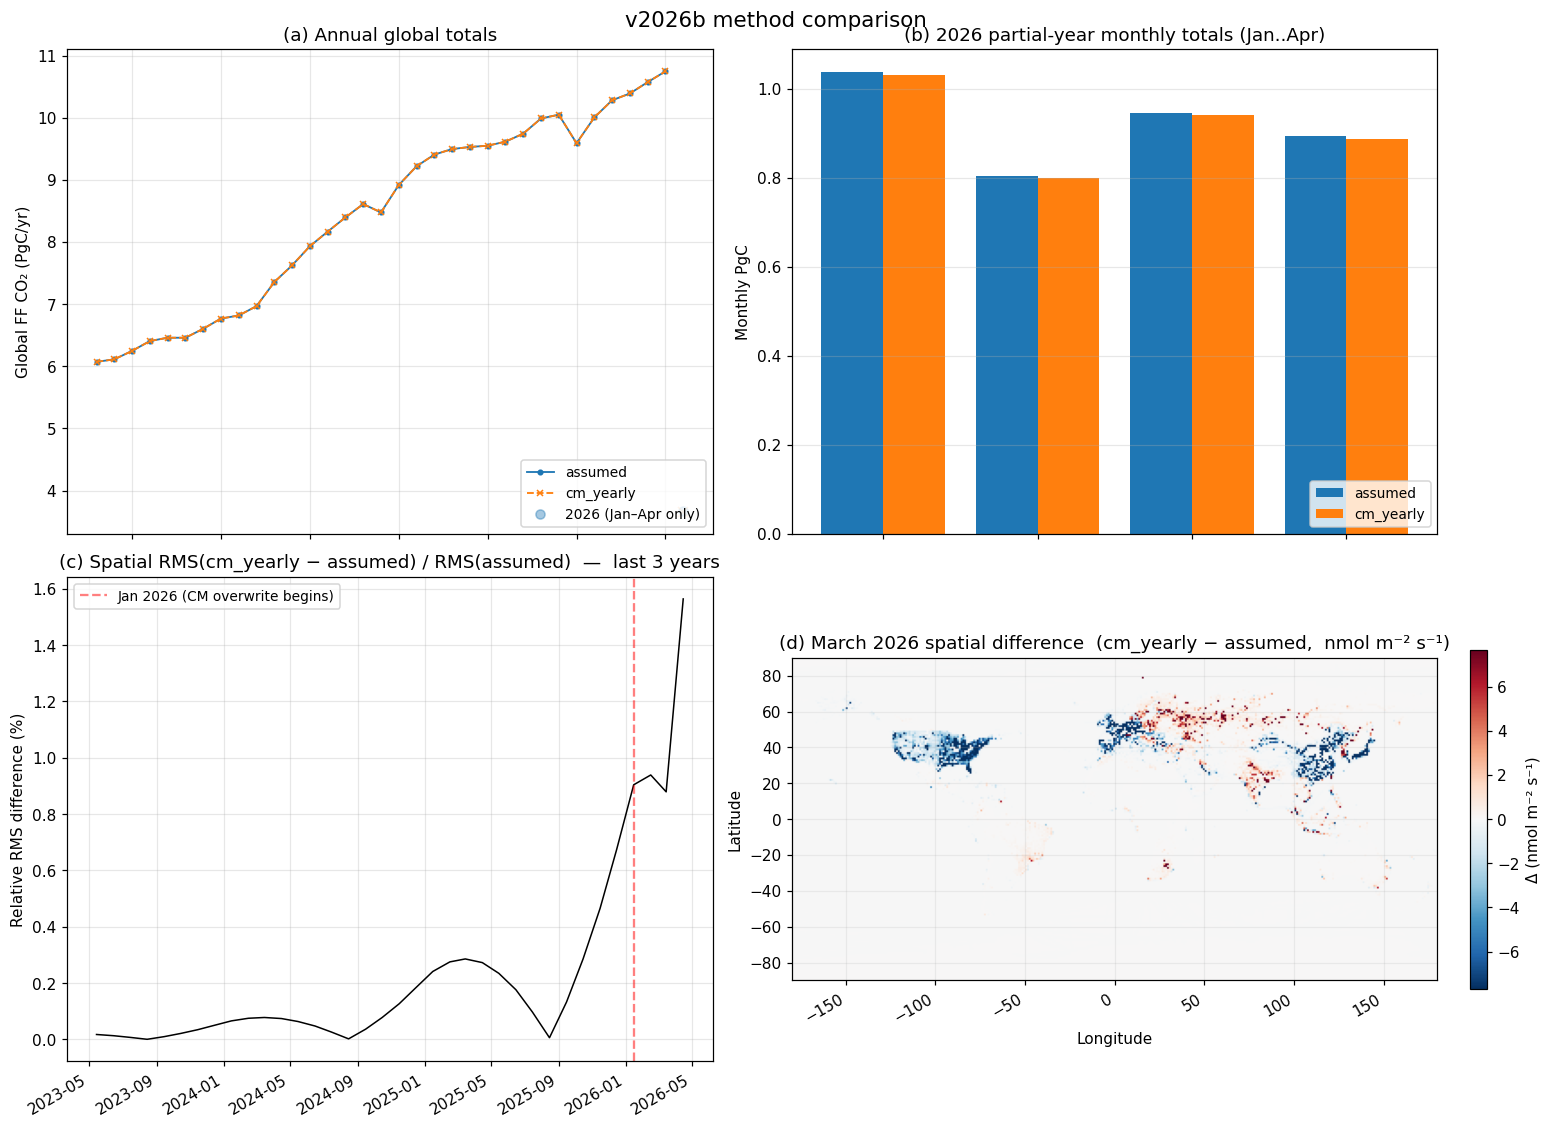

In [3]:
display(Image(filename=str(PNG)))

## Check 12a — partial-year structure

Both NetCDFs should end at 2026-04-15 with 400 months total (33 full years × 12 + 4 partial). The same time axis applies to both.

In [4]:
from collections import Counter

n_months = ds_a.sizes["time"]
assert n_months == 400, f"Expected 400 months, got {n_months}"
assert ds_b.sizes["time"] == 400

times = pd.DatetimeIndex(ds_a.time.values)
assert times[-1].year == 2026 and times[-1].month == 4, f"Last month should be 2026-04, got {times[-1]}"

year_counts = Counter(times.year)
assert year_counts[2025] == 12, f"2025 should have 12 months, got {year_counts[2025]}"
assert year_counts[2026] == 4, f"2026 should have 4 months, got {year_counts[2026]}"
print("PASS: 33 full years (1993-2025) + 4 partial months (2026-01..2026-04) on both NetCDFs")

PASS: 33 full years (1993-2025) + 4 partial months (2026-01..2026-04) on both NetCDFs


## Check 12b — CM monthly overwrite was applied to Feb/Mar 2026

The pipeline overwrites Feb..Apr 2026 with `Jan_2026 × CM_monthly_ratio[country]`, with a WORLD ratio for ocean / bunker cells. We can verify by re-deriving an expected ratio from the WORLD column of `processed_inputs/CM_monthly_ratios_2025-2026.csv` and checking ocean cells against it.

April 2026 is **not** overwritten (CM hasn't published April yet at the time of this run); those April cells should equal whatever the spline + seasonal cycle produced.

In [5]:
cm_mr = pd.read_csv("processed_inputs/CM_monthly_ratios_2025-2026.csv", index_col=0)
cm_2026_cols = [c for c in cm_mr.columns if c.startswith("2026-") and c != "2026-01"]
world_ratios = {c: cm_mr.at["WORLD", c] for c in cm_2026_cols}
print("WORLD CM ratios (relative to Jan 2026), columns present in CSV:")
for c, r in world_ratios.items():
    print(f"  {c}: {r:.4f}")
if "2026-04" not in world_ratios:
    print("  2026-04: not in CM data (April hasn't been released yet)")

# Find a representative ocean cell. Mid-Atlantic at ~30°N, 40°W is reliable shipping ocean.
lat_idx = int(np.argmin(np.abs(ds_a.lat.values - 30.0)))
lon_idx = int(np.argmin(np.abs(ds_a.lon.values - (-40.0))))

for method_name, ds in (("assumed", ds_a), ("cm_yearly", ds_b)):
    fi = ds["fossil_imp"].values  # (time, lat, lon)
    jan_idx = (2026 - 1993) * 12  # 396
    jan_val = fi[jan_idx, lat_idx, lon_idx]
    print(f"\n  [{method_name}] mid-Atlantic ocean cell (~30°N, 40°W):")
    print(f"    Jan 2026 fossil_imp = {jan_val:.3e} mol/m²/s")
    for offset, period in enumerate(["2026-02", "2026-03", "2026-04"], start=1):
        actual = fi[jan_idx + offset, lat_idx, lon_idx]
        ratio = world_ratios.get(period)
        if ratio is not None and pd.notna(ratio):
            expected = jan_val * ratio
            rel_err = abs(actual - expected) / max(abs(expected), 1e-30)
            ok = "PASS" if rel_err < 1e-6 else f"FAIL (rel err {rel_err:.2e})"
            print(f"    {period} actual={actual:.3e}  Jan×{ratio:.4f}={expected:.3e}  {ok}")
        else:
            print(f"    {period} actual={actual:.3e}  (no CM ratio — left untouched)")

WORLD CM ratios (relative to Jan 2026), columns present in CSV:
  2026-02: 0.8592
  2026-03: 0.9114
  2026-04: not in CM data (April hasn't been released yet)

  [assumed] mid-Atlantic ocean cell (~30°N, 40°W):
    Jan 2026 fossil_imp = 2.495e-10 mol/m²/s
    2026-02 actual=2.143e-10  Jan×0.8592=2.143e-10  PASS
    2026-03 actual=2.274e-10  Jan×0.9114=2.274e-10  PASS
    2026-04 actual=2.509e-10  (no CM ratio — left untouched)

  [cm_yearly] mid-Atlantic ocean cell (~30°N, 40°W):
    Jan 2026 fossil_imp = 2.453e-10 mol/m²/s
    2026-02 actual=2.108e-10  Jan×0.8592=2.108e-10  PASS
    2026-03 actual=2.236e-10  Jan×0.9114=2.236e-10  PASS
    2026-04 actual=2.435e-10  (no CM ratio — left untouched)


## Check 12c — methods agree exactly through 2024 (no extrapolation)

1993-2024 in both files comes straight from CDIAC (1993-2022) + EI ratios (2023-2024). No method-dependent code touches these years; they should be byte-identical to within float64 precision.

In [6]:
fa = ds_a["fossil_imp"].values
fb = ds_b["fossil_imp"].values

# Months 0..(2024-1993+1)*12 = 0..384 are 1993-01..2024-12
n_pre = (2024 - 1993 + 1) * 12  # 384

def diff_summary(label: str, slc: slice) -> tuple[float, float, float]:
    """Return (max abs diff, RMS abs diff, 99th-pct abs diff)."""
    a, b = fa[slc], fb[slc]
    abs_diff = np.abs(b - a)
    max_a   = abs_diff.max()
    rms_a   = float(np.sqrt(np.mean(abs_diff ** 2)))
    p99_a   = float(np.percentile(abs_diff, 99))
    rms_ref = float(np.sqrt(np.mean(a ** 2)))
    rel_rms = rms_a / rms_ref if rms_ref > 0 else 0.0
    print(f"  {label:24s}  max |Δ| = {max_a:.3e}   RMS |Δ| = {rms_a:.3e}   "
          f"p99 |Δ| = {p99_a:.3e}   rel-RMS = {100*rel_rms:.3f}%")
    return max_a, rms_a, rel_rms

# PIQS is a global tridiagonal spline — changing the 2026 boundary propagates
# back through the solve, so 1993-2024 isn't byte-identical between methods.
# The propagation is bounded; we expect rel-RMS < ~1% for pre-2026 years and
# the divergence to concentrate in 2026 itself.
_,  _, rel_pre  = diff_summary("1993-2024 (n=384 months)", slice(0, n_pre))
_,  _, rel_2025 = diff_summary("2025      (n=12 months) ", slice(n_pre, n_pre + 12))
abs_2026, _, rel_2026 = diff_summary("2026 Q1   (n=4 months)  ", slice(n_pre + 12, None))

# Sanity: spline-propagation noise stays well under 1%, and the 2026 divergence
# is at least an order of magnitude larger than the pre-2026 noise.
assert rel_pre  < 0.01, f"1993-2024 rel-RMS should be < 1%, got {rel_pre:.2%}"
assert rel_2025 < 0.01, f"2025 rel-RMS should be < 1%, got {rel_2025:.2%}"
assert rel_2026 > rel_pre * 5, (
    f"2026 divergence ({rel_2026:.2%}) should be >> pre-2026 spline noise "
    f"({rel_pre:.2%})"
)
print("\nPASS: pre-2026 differences are bounded spline-propagation noise; "
      "2026 diverges as expected (>5× larger than pre-2026).")

  1993-2024 (n=384 months)  max |Δ| = 8.686e-08   RMS |Δ| = 6.981e-11   p99 |Δ| = 1.713e-12   rel-RMS = 0.021%
  2025      (n=12 months)   max |Δ| = 3.249e-07   RMS |Δ| = 1.423e-09   p99 |Δ| = 2.083e-09   rel-RMS = 0.335%
  2026 Q1   (n=4 months)    max |Δ| = 6.537e-07   RMS |Δ| = 4.863e-09   p99 |Δ| = 9.284e-09   rel-RMS = 1.094%

PASS: pre-2026 differences are bounded spline-propagation noise; 2026 diverges as expected (>5× larger than pre-2026).
